# 02 - Preprocessing

## Objective To:
Clean the dataset, remove duplicates, split features and target, create a stratified train/validation/test split, scale only `Time` and `Amount`.

In [28]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import joblib

In [29]:
data_path = Path("../data/creditcard.csv")
df = pd.read_csv(data_path)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Duplicate Handling

Duplicate rows are removed before splitting: so the same transaction pattern does not appear in both training and test data. 

In [30]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

df = df.drop_duplicates(keep="first")
print("Dataset shape after duplicate removal:", df.shape)

Duplicate rows found: 1081
Dataset shape after duplicate removal: (283726, 31)


## Feature and Target Split

In [31]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


## Train / Validation / Test Split

The project uses a strict split:

- Training set: fit models and preprocessing.
- Validation set: tune thresholds, compare models, and choose hyperparameters.
- Test set: final unbiased evaluation only after model and threshold choices are fixed.

All splits are stratified to preserve the rare fraud rate.

In [32]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

validation_fraction_of_train_full = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=validation_fraction_of_train_full,
    random_state=42,
    stratify=y_train_full
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (198608, 30) y_train: (198608,)
X_val: (42559, 30) y_val: (42559,)
X_test: (42559, 30) y_test: (42559,)


In [33]:
split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index() * 100,
    "validation": y_val.value_counts(normalize=True).sort_index() * 100,
    "test": y_test.value_counts(normalize=True).sort_index() * 100,
})

split_distribution

,train,validation,test
Class,,,
0,99.83334,99.833173,99.833173
1,0.16666,0.166827,0.166827


## Scaling

Only `Time` and `Amount` are scaled. The scaler is fitted on the training set only, then applied to validation and test sets to avoid data leakage.

In [34]:
scaler = StandardScaler()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

columns_to_scale = ["Time", "Amount"]

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_val[columns_to_scale] = scaler.transform(X_val[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

X_train[columns_to_scale].describe()

,Time,Amount
count,1.986080e+05,1.986080e+05
mean,9.645247e-17,-2.146568e-17
std,1.000003e+00,1.000003e+00
min,-1.997996e+00,-3.643288e-01
25%,-8.569592e-01,-3.408645e-01
50%,-2.142028e-01,-2.733186e-01
75%,9.363671e-01,-4.311147e-02
max,1.642166e+00,8.073016e+01


In [35]:
output_path = Path("../outputs/results_corrected")
output_path.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "scaler": scaler,
        "columns_to_scale": columns_to_scale,
    },
    output_path / "creditcard_cleaned.pkl"
)

print("Processed data saved to:", output_path / "creditcard_cleaned.pkl")

Processed data saved to: ..\outputs\results_corrected\creditcard_cleaned.pkl


## Saved Preprocessing Figures

These figures document what changed during preprocessing and confirm that stratification preserved the rare fraud class across train, validation, and test splits.


D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\preprocessing_duplicate_rows_summary.png


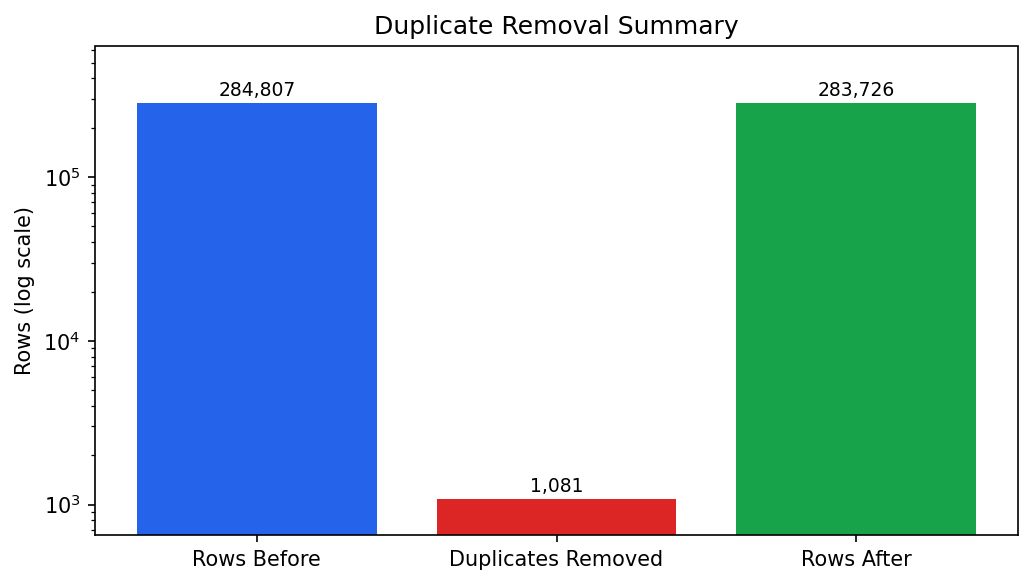

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\preprocessing_split_class_distribution.png


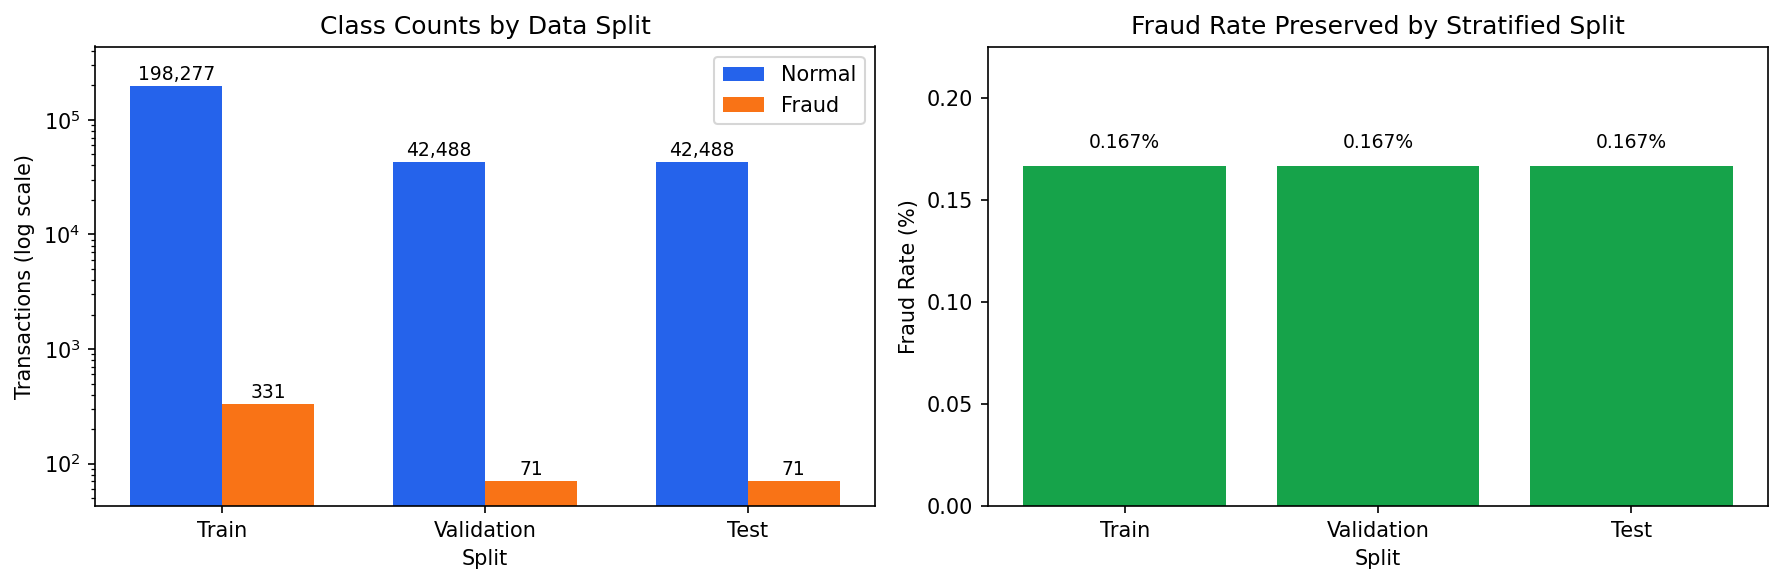

In [36]:
import sys
from IPython.display import Image, display

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import (
    save_duplicate_summary_plot,
    save_split_class_distribution_plot,
)

figures_dir = project_root / "outputs" / "figures"
processed_data = joblib.load(output_path / "creditcard_cleaned.pkl")
raw_df_for_figures = pd.read_csv(data_path)

saved_preprocessing_figures = [
    save_duplicate_summary_plot(raw_df_for_figures, df, figures_dir),
    save_split_class_distribution_plot(processed_data, figures_dir),
]

for figure_path in saved_preprocessing_figures:
    print(figure_path)
    display(Image(filename=str(figure_path)))


## Preprocessing Figure Interpretation

The duplicate-removal summary shows the number of rows before cleaning, the duplicate rows removed, and the final number of rows used for modelling. Removing duplicates before splitting reduces the risk that repeated transaction patterns appear in both training and evaluation data.

The split-distribution figure confirms that the train, validation, and test sets preserve the same rare fraud rate. This is important because threshold tuning and final testing should be performed on splits with the same class imbalance as the original problem.


## Preprocessing Summary

- Duplicate rows were removed before data splitting.
- The data was split into train, validation, and test sets using stratification.
- `Time` and `Amount` were scaled using a training-only scaler.
- The validation set will be used for threshold tuning and model selection.
- The test set will be used only for final model evaluation.
- Report-ready preprocessing figures were saved to `outputs/figures`.
